# Tutorial: Processing Scanning 3DXRD Data Using Friedel Pairs
Written by Jean-Baptiste Jacob

Last updated: 18/02/2025

## Introduction

Scanning 3-Dimensional X-ray Diffraction (s3DXRD), or point-focused High Energy Diffraction Microscopy (pf-HEDM), is a variation of the 3DXRD/HEDM technique ([Poulsen, 2004](https://link.springer.com/book/10.1007/b97884), [Bernier et al., 2011](https://doi.org/10.1177/0309324711405761)) used to map crystallographic orientation and strain within a 3D volume. It uses a pencil-beam setup, where the sample is translated and rotated multiple times to successively illuminate different sub-volumes of the sample with the incident beam. Although the acquisition time is significantly increased compared to regular 3DXRD/HEDM with a larger line-focus or box beam, s3DXRD provides much richer information on the internal crystal orientation and strain field. It allows complete reconstruction of grain shapes and mapping of intra-grain variations in orientation and strain.

However, processing 3DXRD data can be time-consuming and tedious. The "normal" procedure involving grain fitting and reconstruction from the sinogram (["tomographic route"](https://github.com/FABLE-3DXRD/ImageD11/tree/master/ImageD11/nbGui/S3DXRD)) in ImageD11 tutorial can appear somewhat non-intuitive and is not suited for complex samples (many phases, large deformation). The alternative ''point-by-point'' indexing works better in such cases but the procedure detailed in ImageD11 may fail for large (> a few mm), multi-phase samples like rocks, concrete or ceramics. 

An alternative procedure has been developed ([Jacob et al., 2024](https://doi.org/10.1107/S1600576724009634)), which exploits the symmetric properties of Friedel pairs to process s3DXRD datasets. Friedel pairs are symmetric reflections  **(h,k,l)** and **(-h,-k,-l)** arising from the same grain, which occur at 180° offset during a full 360° rotation of the sample along an axis perpendicular to the beam. Using the symmetric properties of these pairs, it is possible to clearly separate the component of the apparent diffraction vectors related to lattice orientation and spacing (the "true" diffraction vector) from the component related to spatial offset from the rotation center (which provides information on the position of the diffracting source in the sample).

Identifying Friedel pairs in a 3DXRD dataset thus enables treating indexing and grain position fitting as two independent problems, which considerably simplifies data analysis, especially in complex samples such as polyphased, highly strained polycrystalline materials.

This tutorial aims to guide you step-by-step to obtain an indexed grain map starting from segmented diffraction peaks, using the Friedel pair method. This processing pipeline is based on [ImageD11](https://github.com/FABLE-3DXRD/ImageD11) but has been developed independently of the workflows provided in `ImageD11/nbGui/S3DXRD`. The intermediate processing steps employs custom tools provided in [pf3dxrd](https://github.com/jbjacob94/pf3dxrd). Final outputs (orientation and strain maps) are saved as an HDF5 file that can be visualized with a custom class `Pixelmap` provided in `pf3dxrd`, similar to the `TensorMap` class in ImageD11. Conversion from `Pixelmap` to `TensorMap` is straightforward using a built-in method. 

#### Requirements:

##### Software
- A functional Python environment (3.9 or above) installed on your machine, with Jupyter notebooks.
- The [ImageD11](https://github.com/FABLE-3DXRD/ImageD11) module to process 3D X-ray diffraction data. Check [here](https://github.com/FABLE-3DXRD/ImageD11) for details on installation.
- So far, pf3dxrd is not a proper package and only consists of a collection of python modules and scripts. To use it, just clone the repository to your project folder and make sure it appears in `sys.path'

`git clone git@github.com:jbjacob94/pf3dxrd.git`

If you work from the ESRF Nice cluster, everything should already be setup, except the `pf3dxrd` module which has to be cloned in the working directory. 

##### Data Acquisition & Pre-processing
- Data acquisition must be done applying full 360° rotations of the sample along the z-axis (vertical), in order to get symmetric **(h,k,l)** and **(-h,-k,-l)** reflections (''omega-pairs'' 180° apart during a full rotation about the z-axis). **180° scans are not suitable** for the Friedel Pairs technique.
- The raw diffraction frames have been segmented into discrete diffraction peaks and stored in a peak table (check the notebook [0_segment_and_label.ipynb](https://github.com/FABLE-3DXRD/ImageD11/tree/master/ImageD11/nbGui/S3DXRD)).
- A dataset file (`ImageD11.sinograms.dataset`) containing information about the range and step size of scanning (ystep, ybins, obins, etc.) has been created.
- The detector has been properly calibrated, with calibration parameters (tilt, center, distance, etc.) stored in an ImageD11 parameter file (`*.par`).

#### Example Datasets
Example datasets are provided in the folder `/data`.

- **SI3_DT360Z5480** : 2.5x5 mm chunk of [Westerly granite](https://scholars.unh.edu/cgi/viewcontent.cgi?article=1056&context=neigc_trips) with a mineral assemblage of **quartz**, **biotite**, **orthoclase** (K-feldspar), **oligoclase** (plagioclase), and accessory minerals like **magnetite** (other accessory phases like zircon, monazite, etc. are not considered). It was scanned at the 3DXRD station of ID11 (ESRF), using a 50x50 µm pencil beam and angular steps of 0.8°. Corresponds to WG_SI3 sample in [Jacob et al. (2024)](https://journals.iucr.org/j/issues/2024/06/00/nb5388/). Peak segmentation was done using old, deprecated code and has no peak table assigned, so only a peakfile (ImageD11 columnfile saved in HDF format) is provided. This dataset is relatively small and should be manageable on a personal machine without crashing.

- **C18A_01_z180** : 800 µm circular region of interest across a ca. 1.5x2 mm slab of rock. The sample is an ultra-high-pressure metamorphic rock from the [Lago di Cignana unit](https://onlinelibrary.wiley.com/doi/10.1111/j.1525-1314.2009.00814.x), Italy. The rock contains an assemblage composed dominantly of **quartz** and **garnet**, with other accessory minerals like rutile or zircon that are not considered here. The dataset is a slice of the 3D dataset shown in [Jacob et al., 2025](https://www.sciencedirect.com/science/article/pii/S0012821X25004133), consisting of 20 slices scanned with a 7.5x7.5 µm beam and 0.05° angular step size on the nanofocus station of ID11 at ESRF.  

- **FBS_H0524_01_10MPa** : slice across a 5mm diameter core low-porosity Fontainebleau sandstone, mainly composed of **quartz**. Other accessory minerals are not considered. It was scanned on the large sample stage of ID11 (ESRF) in EH1, using 0.8° angular step size and a 50x50 µm beam. This dataset is part of [Jacob et al., 2025](agupubs.onlinelibrary.wiley.com/doi/10.1029/2025JB031614?af=R), where cores of sandstone were deformed in quasi-stiatic triaxial compression to study in situ the evolution of internal stress distribution in quartz. The 10 MPa dataset corresponds to the initial loading stage at 10 MPa differential stress (10 MPa radial confinement and 20 MPa axial stress).


##### Folder contents
Each dataset includes:
- A HDF5 peakfile `*_pk2d.h5` containing segmented 2D peaks (esxcept for C18A_01_z180, see below)
- A filtered peakfile `*_pk2d_flt"` containing paired peaks with Friedel pair labels
- A `Pixelmap` HDF5 file `*_xmap.h5` for storing final outputs as 2D maps.
- Metadata stored in an `ImageD11.sinogram.dataset` object: `*_dataset.h5`
- A parameter file containing detector calibration parameters: `*.par`
- For data acquired with a Frelon detector, a splinefile (*.spline) for detector distortion correction

In addition, crystal structures for all the minerals needed for this tutorial are provided as CIF files in the `/cif` folder.

For **C18_01_z180**, a peaks table `*_peaks_table.h5"` is provided instead of the peak file to show the full procedure starting from the peaks table created from the sparse file ("Peaks labeling" in S3DXRD Tutorial [0_segment_and_label](https://github.com/FABLE-3DXRD/ImageD11/blob/master/ImageD11/nbGui/S3DXRD/0_segment_and_label.ipynb)). 


#### Recommandations
- **SI3_DT360Z5480**: relatively small dataset (~4M peaks) with multiple phases, good to start with as the raw peakfile is quite messy and illustrates quite well the full power of Friedel pairs to work with complex data. All the tutorials were initially written for this sample, so going through the notebooks should be quite straightforward. For indexing: try to index quartz first (the easiest), then move on to feldspars (more complex). Biotite tends to split easily along its basal cleavage plane, which makes indexing very challenging because each grain has many very thin cleavage planes separating slightly misoriented domains. I have not managed to get decent indexing with this mineral yet.  
- **FBS_H0524_01_10MPa**: single phase (quartz), many grains, relatively easy to index. Good to move on and gets training on indexing. 
- **C18A_01_z180**: High resolution dataset acquired on the nanofocus station with the Eiger detector. Illustrates the whole procedure starting from the peaks table, and shows the full potential of scanning-3DXRD with a high angular resolution. Only two phases to index (quartz and garnet), that are relatively easy to separate (no complex intergrowths or twins). This dataset is much larger than the others (~80M peaks), maybe a bit large for processing outside the ESRF cluster.


## Summary
This tutorial is divided into five parts, corresponding to different notebooks:
- **Tuto_001_Friedel_Pairs_Match.ipynb**: Find Friedel pairs in a set of segmented peaks, assign them a label, and store the paired peaks in a new ImageD11 columnfile (custom ImageD11 object for storing diffraction peaks).
- **Tuto_002_Phase_Labelling.ipynb**: Point-by-point phase labeling. Map peaks to pixels on a 2D map and find the best-matching phase for each pixel, from a list of pre-determined crystal structures. Also filter peaks in the peakfile and assign them a phase label.
- **Tuto_003_Local_Indexing.ipynb**: Point-by-point indexing: Find for each pixel the unit cell matrix ($UBI$) that matches the best with the reciprocal lattice vectors (g-vectors) and refine the unit cell based on the g-vector selection.
- **Tuto_004_Grain_Mapping**: Grain boundary identification and grain mapping based on angular misorientation threshold.
- **Tuto_004b_Grain_Mapping_DBSCAN**: An alternative grain-mapping strategy using the DBSCAN algorithm. Define grains by clustering pixels/voxels in symmetry-reduced orientation space. Inspired by [orix](https://orix.readthedocs.io/en/latest/tutorials/clustering_across_fundamental_region_boundaries.html). Read [Johnstone et al. 2020](https://arxiv.org/abs/2001.02716) for more details.
- **Tuto_005_Strain_Stress_Mapping.ipynb**: Map strain and stress to pixels and grains.

Shorter notebooks (without the 'Tuto' prefix) are provided in the `Examples` folder, with less detailed explanation, that are aimed to serve as a starting base to build your processing workflow.

# Part 1: Friedel Pairs Matching

The first part of the process consists in finding **Friedel pairs** among the set of segmented diffraction peaks. Each pair will be assigned a unique label, so they can be rapidly identified in subsequent steps.

### Load packages

In [1]:
import sys

# python environment stuff
IMAGED11_PATH = None  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = None  # the name of the git checkout folder within path. None means guess

if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    PYTHONPATH = install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)
else:
    import site
    PYTHONPATH = site.getsitepackages()[0]
    print(PYTHONPATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [31]:
# General modules
import os
import h5py
import matplotlib.pyplot as pl
import numpy as np

# ImageD11: https://github.com/FABLE-3DXRD/ImageD11
import ImageD11.sinograms.dataset
ImageD11.sparseframe, ImageD11.blobcorrector, ImageD11.columnfile

# pf_3dxrd: Friedel Pair scanning 3DXRD module
# Available at: https://github.com/jbjacob94/pf_3dxrd
# Not yet installable with pip; copy the files into your working folder. Do not forget to add the folder in your sys.path if it is not the case already: sys.path.append('my_path')
from pf3dxrd.pf3dxrd import utils, friedel_pairs, crystal_structure

# Jupyter settings
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Loading Data

Peaks segmented from the sparse file are stored in a **peak table** (`*_peaks_table.h5`) containging 2D peaks segmented from the sparse matrix of each 2D frame in the raw data. This table can be exported to a peakfile (ImageD11 columnfile class), which is the base format to work with peaks. Data can be loaded in either one or the other format in the `load_data` function below. Just chose the appropriate format (`input_format = 'peakfile'` or `input_format = 'peaktable'`).

Metadata, including file paths and acquisition parameters (rotation and translation steps, etc.), are stored in a **"Dataset" file** (`*_dataset.h5`). 

#### 2D, 3D, 4D peaks
Diffraction data are treated as discrete peaks with a given intensity. However, the real data consist in pixel clusters with variable intensity profiles and spread. ImageD11 works by integrating each clusters to find their total intensity and centroid position, which are then treated as a discrete vector orientation in reciprocal space (gvector). There are several integration schemes, providing either 2D, 3D or 4D peaks:

- **2D peaks** are raw peaks segmented from 2D detector images ($y_{det}$, $z_{det}$), and correspond to diffraction acquired at a single angular and translation step.
- **3D peaks** are merged in $\omega$ ($y_{det}$, $z_{det}$, $\omega$) and correspond to diffraction intensity integrated over the full angular spread of the peak in $\omega$. **This is only consistent for box-beam data, where the full grain is illuminated over the rotation.** In s3DXRD, the illuminated sub-domain changes at every $\omega$ step, so using 3D integration is dodgy.  
- **4D peaks** are merged both in rotation ($\omega$) and translation ($dty$), so that the diffraction spots arising from the same grain at different translation steps are merged together. This allows to reconstruct "box-beam-like" data from pencil-beam scanning data, with a complete mapping between 2D and 4D peaks (i.e, the 2D peaks merged within the same 4D peak can be easily identified). This merging is the base of the "tomographic" indexing route in ImageD11, where 4D peaks are indexed first and then each grain reconstruction is obtained from the sinogram of corresponding 2D peaks. 


**Friedel pair search can be performed on every type of peaks**, as long as ($2\theta$, $\eta$, $\omega$, $dty$) peak centroids can be computed. However, the specific indexing route detailed in this tutorial **works only with 
2D peaks**.

In [156]:
def load_data(dsname, parfile, input_format = 'peaktable', return_2D_peaks=False):
    """ 
    load data from peakfile or peaktable 
    
    Args:
    ----------
    dsname (str) : dataset name
    parfile (str): parameter file name
    input_format (str) : either 'peaktable' or 'peakfile'. Control whether data is loaded from an ImageD11 peak table or from a simple peakfile 
    return_2D_peaks (bool): returns 2D peaks instead of 3D peaks (merged in omega) are returned. Only relevant for data loaded from a peak table
                            default is False
    
    Returns:
    cf : ImageD11 columnfile
    ds : ImageD11 dataset
    """
    ####################################
    assert input_format in ['peakfile', 'peaktable'], 'input_format must be either "peakfile" or "peaktable" '
    
    # paths
    ####################################
    if input_format == 'peaktable':
        pksfile = os.path.join(data_dir, dsname+'_peaks_table.h5')
        dsfile  = pksfile.replace('peaks_table','dataset')
    else:
        pksfile = os.path.join(data_dir, dsname+'_pk2d.h5') 
        dsfile  = pksfile.replace('pk2d','dataset')
   
    
    # load ds file and peaks dictionary
    ####################################
    ds = ImageD11.sinograms.dataset.load(dsfile)

    print(f'Loading data for dataset {ds.dsname}: \n==============================')    
    items = 'n_ystep,n_ostep,ymin,ymax,ystep,omin,omax,ostep'.split(',')
    vals  = [ds.shape[0], ds.shape[1], ds.ymin, ds.ymax, ds.ystep, ds.omin, ds.omax, ds.ostep]
    for i,j in zip(items, vals):
        print(f'{i}: {j:.1f}')
        
    print('==============================')
        
    if input_format == 'peakfile':
        print('loading peakfile...')
        pks = ImageD11.columnfile.columnfile(pksfile)
        pkd = {t:pks.getcolumn(t) for t in pks.titles}
         
    else:
        print('loading peaks from peak table...')
        pkst = ImageD11.sinograms.properties.pks_table.load(pksfile)
        
        print('merging peaks...')
        if return_2D_peaks:      
            pkd = pkst.pk2d( ds.omega, ds.dty )         # for 2D peaks
        else:
            pkd = pkst.pk2dmerge( ds.omega, ds.dty )    # for 4D peaks
            
    cf = ImageD11.columnfile.colfile_from_dict(pkd)
    print(f'loaded peakfile: nrows = {cf.nrows}')
    utils.get_colf_size(cf)
    
    return cf, ds


In [212]:
# define paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

dsname = 'SI3_DT360Z5480'
#dsname = 'C18A_01_z180'
parfile= data_dir+'SI3.par'
#parfile = data_dir+'C18A_01.par'

splinefile = data_dir+'/frelon21_mar16.spline'

# load data
cf, ds = load_data(dsname, parfile, input_format='peakfile', return_2D_peaks=True)

Loading data for dataset SI3_DT360Z5480: 
n_ystep: 109.0
n_ostep: 450.0
ymin: -2.7
ymax: 2.7
ystep: 0.1
omin: 0.0
omax: 360.0
ostep: 0.8
loading peakfile...
Reading your columnfile in hdf format
loaded peakfile: nrows = 4104546
Total size =  93.95 MB


Let's have a look at loaded data. 

In [213]:
cf.titles

['omega', 's_raw', 'f_raw', 'sum_intensity', 'dty', 'number_of_pixels']

The peakfile should contain the following columns:
   Column            | Description                                                                                     |
 |-------------------|-------------------------------------------------------------------------------------------------|
 | `omega`           | Rotation angle of the sample (along the z-axis) on the diffractometer.                         |
 | `s_raw`           | Raw coordinate of the peak center-of-mass on the detector (slow scan direction).               |
 | `f_raw`           | Raw coordinate of the peak center-of-mass on the detector (fast scan direction).               |
 | `sum_intensity`   | Sum of the intensity of all pixels integrated in each peak.                                     |
 | `spot3d_id`       | Unique index for each 3D peak, used to relate 2D peaks to 3D peaks in the peaks table.          |
 | `dty`             | Sample translation along the y-axis (units: mm or µm, depending on the experimental setup).     |
 | `number_of_pixels`| Total number of pixels integrated in each peak.                                                |

**Notes:**
- `sum_intensity` and `number_of_pixels` are strongly correlated and relate to the total peak size and intensity.
- In this tutorial, `spot3d_id` is irrelevant since we are working only with 2D peaks.

### Distortion correction

cf contains raw data columns `f_raw` and `s_raw` with raw peak coordinates on the detector. These coordinates need to be corrected for detector distortion. Different methods exist depending on the detector used for data acquisition. For the eiger detector of ID11 (nanoscope station), pre-computed distorsion images (dxfile, dyfiles) are provided, which allow fast distortion correction. For the frelon detector (3DXRD station), a splinefile is provided, from which a pixel lookup table is made, which gives the (dx,dy) correction for each pixel.

If you don't know which detector has been used, this should be precised in the metadata (dataset file). 

In [214]:
ds.detector

'frelon'

In [206]:
def correct_distortion_eiger( cf, parfile,
              dxfile="/data/id11/nanoscope/Eiger/spatial_20210415_JW/e2dx.edf",
              dyfile="/data/id11/nanoscope/Eiger/spatial_20210415_JW/e2dy.edf"):
    
    """ 
    FOR EIGER DATA. Apply detector distortion correction for eiger data, using pre-computed disortion files. 
    Adds on the geometric computations (tth, eta, gvector, etc.)
    
    Args: 
    ---------
    cf : ImageD11 columnfile
    parfile (str) : parameter file
    dxfile, dyfile : detector distortion. Default files are valid for the eiger detector on the nanofocus station at ID11 
    """
    
    spat = ImageD11.blobcorrector.eiger_spatial( dxfile = dxfile, dyfile = dyfile )
    cf = ImageD11.columnfile.colfile_from_dict( spat( {t:cf.getcolumn(t) for t in cf.titles} ) )
    cf.parameters.loadparameters(parfile)
    cf.updateGeometry()
    return cf


def correct_distortion_frelon( cf, parfile, splinefile):
    """ 
    FOR FRELON DATA. Apply detector distortion correction using a pixel look up table computed from a splinefile. 
    Adds on the geometric computations (tth, eta, gvector, etc.)
    
    Args: 
    ---------
    cf : ImageD11 columnfile
    parfile (str) : parameter file
    splinefile    : detector distortion splinefile
    detector_dim  : (X,Y) detector dimensions  
    """
    
    spat = ImageD11.blobcorrector.correctorclass(splinefile)
    
    # make pixel_lut  + substract xy grid coordinate (i,j) to keep only dx and dy arrays.
    spat.make_pixel_lut(spat.dim)
    i, j = np.mgrid[ 0:spat.dim[0], 0:spat.dim[1] ]
    dx = spat.pixel_lut[0] - i
    dy = spat.pixel_lut[1] - j
    
    # get integer pixel index (si,fi) of each peak
    si = np.round(cf['s_raw']).astype(int)
    fi = np.round(cf['f_raw']).astype(int)
    
    # apply dx dy correction on s_raw / f_raw
    sc = (dx[ si, fi ] + cf.s_raw).astype(np.float32)
    fc = (dy[ si, fi ] + cf.f_raw).astype(np.float32)
    
    # add corrected arrays as new columns
    cf.addcolumn(sc, 'sc')
    cf.addcolumn(fc, 'fc')
    
    # load parameters and update geometry
    cf.parameters.loadparameters(parfile)
    cf.updateGeometry()
    
    return cf

In [215]:
# detector correction distorsion with frelon data
cf = correct_distortion_frelon( cf, parfile, splinefile)


# detector correction distorsion with eiger data. You may want to use different dxfile/dyfile depending on when and where your data were acquired. 
#cf = correct_distortion_eiger(cf, parfile)

cf.titles

copied an array: size=4104546, elsize=4
copied an array: size=4104546, elsize=4
copied an array: size=4104546, elsize=4


['omega',
 's_raw',
 'f_raw',
 'sum_intensity',
 'dty',
 'number_of_pixels',
 'sc',
 'fc',
 'xl',
 'yl',
 'zl',
 'tth',
 'eta',
 'ds',
 'gx',
 'gy',
 'gz']

Several new columns have been added:
   Column | Description                                                                                     |
 |--------|-------------------------------------------------------------------------------------------------|
 | `sc`   | Peak coordinate on the 2D detector after distortion correction (slow scan direction).         |
 | `fc`   | Peak coordinate on the 2D detector after distortion correction (fast scan direction).         |

All other new columns relate to **diffraction vectors**, expressed in different coordinate systems:
 | Column | Description                                                                                     |
 |--------|-------------------------------------------------------------------------------------------------|
 | `(xl, yl, zl)` | Diffraction vector coordinates in the **Cartesian laboratory reference frame**.              |
 | `(tth, eta)` | Diffraction angles: **two-theta** (radial) and **eta** (azimuthal) on the detector.             |
 | `(gx, gy, gz)` | Coordinates of **reciprocal lattice vectors** (diffraction vectors in reciprocal space).       |

### Pre-processing
Raw peakfiles obtained after segmentation can be quite noisy, especially if the segmentation threshold was too low to filter out all the background noise. It is usually a good idea to clean up a bit before going further in the processing pipeline. 

4104546


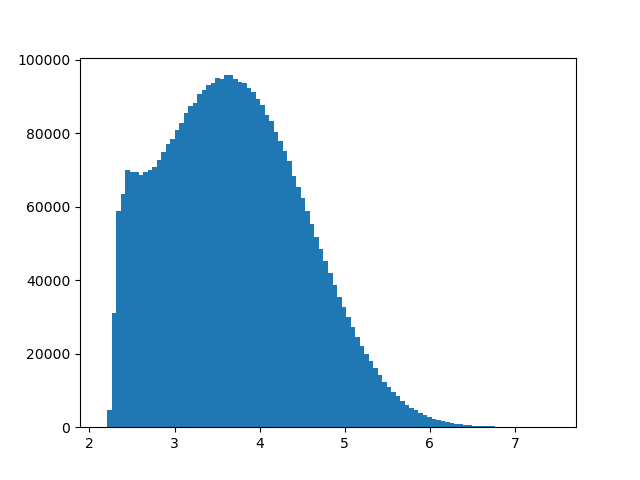

In [216]:
# look at distribution of peak intensity + nb of pixels to decide if data need to be filtered
# Here we see a sharp cut in the distribution at sum_intensity = 150, because the data have been previously filtered.

pl.figure()
pl.hist(np.log10(cf.sum_intensity),bins=100);
print(cf.nrows)

In [217]:
# This is how to filter data, if needed
cf.filter(cf.sum_intensity>20)
cf.filter(cf.number_of_pixels>3)   # column title might be 'Number_of_pixels' or 'number_of_pixels' depending on the detector

cf.nrows

3863533

**two-theta / d-spacing threshold**: keep only peaks from complete diffraction rings. Incomplete rings cropped at the detector boundaries should be removed

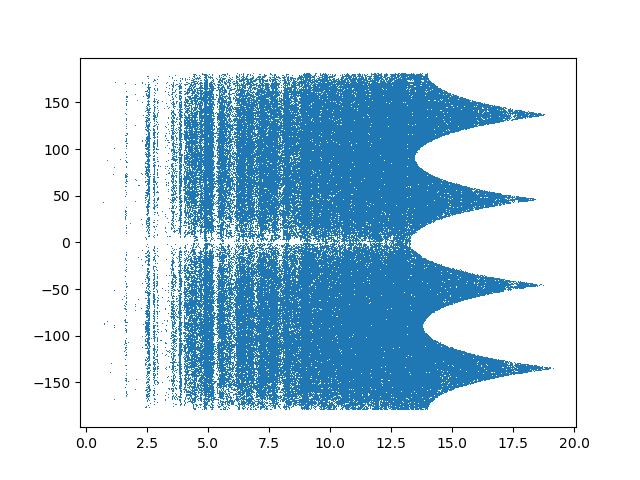

In [218]:
pl.figure()
pl.plot(cf.tth[::10], cf.eta[::10],',')

In [219]:
cf.filter(cf.tth < 13.3)

Friedel pair matching is performed between peaks from **symmetric scans** (`+dty`; `-dty`) acquired at equal distances from the rotation center.
To do this, we first form pairs of `dty` scans, which are then stored in `ds.ypairs`.

In [220]:
# form dty pairs: pairs of (dty,-dty) scans which should contain symmetric information
friedel_pairs.form_y_pairs(cf, ds, disp=True)

dty_center =  -0.00  on bin n° 54
dty pairs: 
-0.0000 ; -0.0000
0.0500 ; -0.0500
0.1000 ; -0.1000
0.1500 ; -0.1500
0.2000 ; -0.2000
0.2500 ; -0.2500
0.3000 ; -0.3000
0.3500 ; -0.3500
0.4000 ; -0.4000
0.4500 ; -0.4500
0.5000 ; -0.5000
0.5500 ; -0.5500
0.6000 ; -0.6000
0.6500 ; -0.6500
0.7000 ; -0.7000
0.7500 ; -0.7500
0.8000 ; -0.8000
0.8500 ; -0.8500
0.9000 ; -0.9000
0.9500 ; -0.9500
1.0000 ; -1.0000
1.0500 ; -1.0500
1.1000 ; -1.1000
1.1500 ; -1.1500
1.2000 ; -1.2000
1.2500 ; -1.2500
1.3000 ; -1.3000
1.3500 ; -1.3500
1.4000 ; -1.4000
1.4500 ; -1.4500
1.5000 ; -1.5000
1.5500 ; -1.5500
1.6000 ; -1.6000
1.6500 ; -1.6500
1.7000 ; -1.7000
1.7500 ; -1.7500
1.8000 ; -1.8000
1.8500 ; -1.8500
1.9000 ; -1.9000
1.9500 ; -1.9500
2.0000 ; -2.0000
2.0500 ; -2.0500
2.1000 ; -2.1000
2.1500 ; -2.1500
2.2000 ; -2.2000
2.2500 ; -2.2500
2.3000 ; -2.3000
2.3500 ; -2.3500
2.4000 ; -2.4000
2.4500 ; -2.4500
2.5000 ; -2.5000
2.5500 ; -2.5500
2.6000 ; -2.6000
2.6500 ; -2.6500
2.7000 ; -2.7000


Plotting the number of peaks / total intensity per dty scan as a function of dty, the $-dty$ and $+dty$ scans should show roughly the same profile, with decreasing intensity with increasing distance from the rotation center. 
In each y-scan pair, both scan should have roughly the same number of peaks assigned. If not, this may have several causes:

- **Misalignment:** The sample is not well centered on the rotation axis. This is not critical and can be fixed (by shifting shift the dty values in cf and ds until the intensity profiles match), but you will need to crop the data afterwards and lose some of the outer regions of the sample.
- **Sample drift:** The sample moved during scanning. This is more problematic, as it causes decorrelation between symmetric (`+dty`, `-dty`) scans, making peak matching unreliable.

NB: variation in beam intensity during the experiment can also cause intensity mistmatch between the two halfs of the data, if no intensity correction has been applied. This typically creates bumps in the profile, where total intensity increases abruptly between two scans. The bump can also appear when plotting number of peaks profiles, as some low-intensity peaks that were filtered out at lower beam intensity suddenly show up in the next scan. 


sorting peakfile by dty scans...
computing stats for each scan...


55it [00:00, 27012.50it/s]


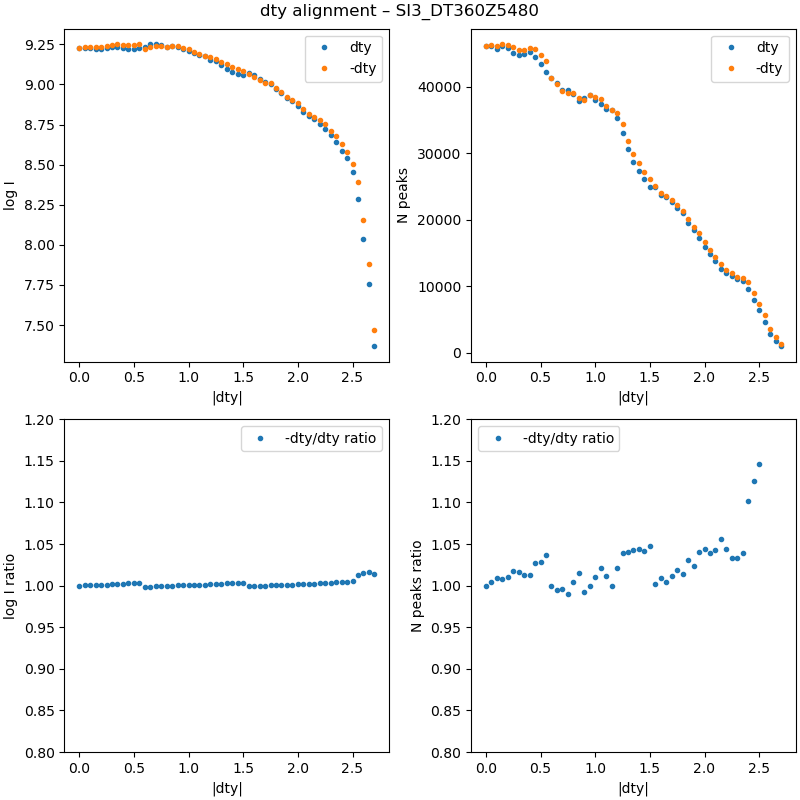

In [221]:
# check dty pairs have roughly the same number of peaks assigned. If not, there is maybe a problem
friedel_pairs.check_y_symmetry(cf, ds, saveplot=False)

For **SI3_DT360Z5480**, the number of peaks and total intensity match very well in each pair of scans. We also observe that both the total intensity and the number of peaks per scan decrease with increasing distance from the rotation center (`dty=0`). This is expected, as the volume illuminated by the beam decreases toward the rim and eventually reaches zero when the beam is fully outside the sample.

The ratios of peak number and log(intensity) oscillate around 1 for most of the y-pairs, with more significant deviations toward the extremities of the sample. The saw-tooth oscillations are related to variations in beam intensity over time, due to the hourly refills at ESRF. This is not problematic, as the peak ratios remain very close to 1. If you observe much larger deviations, there is likely an issue with the data.

### Friedel Pair Labeling

We are now ready to identify Friedel pairs. As a first step, we will test the process on a single pair of scans to visualize the results and tune the parameters for the Friedel pair matching function.

The function `label_friedel_pair` from the `friedel_pairs` module searches for nearest neighbors between two symmetric scans in a **4D space** defined by:
- two-theta (`tth`)
- eta (`eta`)
- omega (`omega`)
- intensity

The parameters `mtth` and `mI` are scaling factors for the two-theta and intensity dimensions, respectively. Adjusting these parameters allows you to control the relative weight of two-theta and intensity in the nearest-neighbor identification. For more details, see the docstring of `friedel_pairs.search_space`.

The matching process runs multiple iterations, each time increasing the distance threshold for nearest-neighbor search by an increment `dist_step`, until the maximum distance `dist_max` is reached. The distance here refers to the Euclidean distance in the 4D search space. A good starting point is usually `dist_max = 1.5` and `dist_step = 0.1`, but the optimal values depend on the scaling parameters `mtth` and `mI`.

If you set `doplot = True`, the function will generate several plots to help evaluate the quality of the pair matches.

8243 pairs kept out of  46084  possible matches
15335 pairs kept out of  37841  possible matches
5938 pairs kept out of  22506  possible matches
2788 pairs kept out of  16568  possible matches
1434 pairs kept out of  13780  possible matches
780 pairs kept out of  12346  possible matches
533 pairs kept out of  11566  possible matches
417 pairs kept out of  11033  possible matches
1023 pairs kept out of  10616  possible matches
555 pairs kept out of  9593  possible matches
405 pairs kept out of  9038  possible matches
384 pairs kept out of  8633  possible matches
310 pairs kept out of  8249  possible matches
322 pairs kept out of  7939  possible matches
217 pairs kept out of  7617  possible matches
Friedel pair matching Completed.
N pairs = 38684 out of 46084 possible candidates
Fraction of peaks matched = 0.84
Fraction of intensity matched = 0.96
dstep_max = 1.500


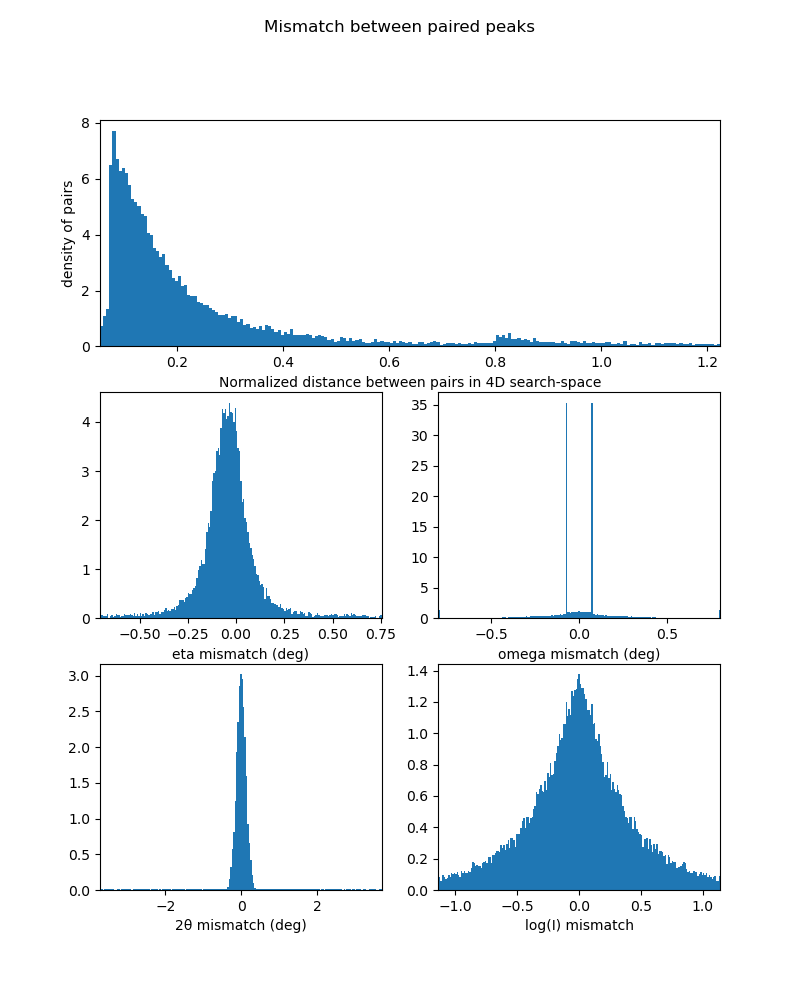

In [222]:
# select peaks from a pair (pair_id no)
c1, c2 = friedel_pairs.select_y_pair(cf, ds, pair_id = 0)

# friedel pair search. let's try first with default values
cp = friedel_pairs.label_friedel_pairs(c1,c2,
                                  dist_max = 1.5,
                                  dist_step = 0.1,
                                  mI=1/5,
                                  mtth=1/4,
                                  verbose=True,
                                  doplot=True)

#### Distance Distribution

The top plot shows the distribution of Euclidean distance between paired peaks in the 4D search space. In an ideal scenario, this distribution should peak at low distances and rapidly decrease toward zero. If this is not the case, try reducing the scaling factors `mtth` and `mI` (reduces the weight of peak intensity and two-theta angle in peak matching, which can differ a bit within a pair)

#### Mismatch Distributions

The other plots show the distribution of peak mismatch along the four dimensions used to build the 4D search space:
- **Eta mismatch** (in degrees)
- **Omega mismatch** (in degrees)
- **Two-theta mismatch** (in degrees)
- **Intensity mismatch** (in log units)

**Interpretation:**
- Large mismatches in eta and omega (>0.5°) should be considered suspicious.
- For two-theta, acceptable mismatch depends on sample size (larger samples imply larger mismatch).
- Intensity mismatch can be significant, especially for stronger peaks (due to beam intensity variations during acquisition and variable absorption of diffracted X-rays through the sample). However, differences larger than one order of magnitude are highly suspicious.

#### Adjusting Parameters

Reducing the values of `mtth` and `mI` usually improves the match in eta and omega, but at the expense of two-theta and intensity (since you are giving more weight to eta and omega and relaxing the constraints on two-theta and intensity). Try to find the right balance, where the mismatch distribution is acceptable for all four dimensions.

#### Dataset-Specific Notes

For the **SI3_DT360Z5480** dataset: 

- large proportion of peaks have been successfully paired: **84% of peaks**, corresponding to **95% of total intensity**. This suggests that peak matches are more easily found between stronger peaks.
- most pairs look acceptable. However, there is a small proportion of suspicious pairs with large mismatches along at least one dimension. To improve results, consider reducing the `dist_max` threshold.

596 pairs kept out of  46084  possible matches
7654 pairs kept out of  45488  possible matches
9562 pairs kept out of  37834  possible matches
5826 pairs kept out of  28272  possible matches
3582 pairs kept out of  22446  possible matches
2322 pairs kept out of  18864  possible matches
1614 pairs kept out of  16542  possible matches
1174 pairs kept out of  14928  possible matches
825 pairs kept out of  13754  possible matches
599 pairs kept out of  12929  possible matches
458 pairs kept out of  12330  possible matches
315 pairs kept out of  11872  possible matches
284 pairs kept out of  11557  possible matches
251 pairs kept out of  11273  possible matches
212 pairs kept out of  11022  possible matches
Friedel pair matching Completed.
N pairs = 35274 out of 46084 possible candidates
Fraction of peaks matched = 0.77
Fraction of intensity matched = 0.92
dstep_max = 0.750


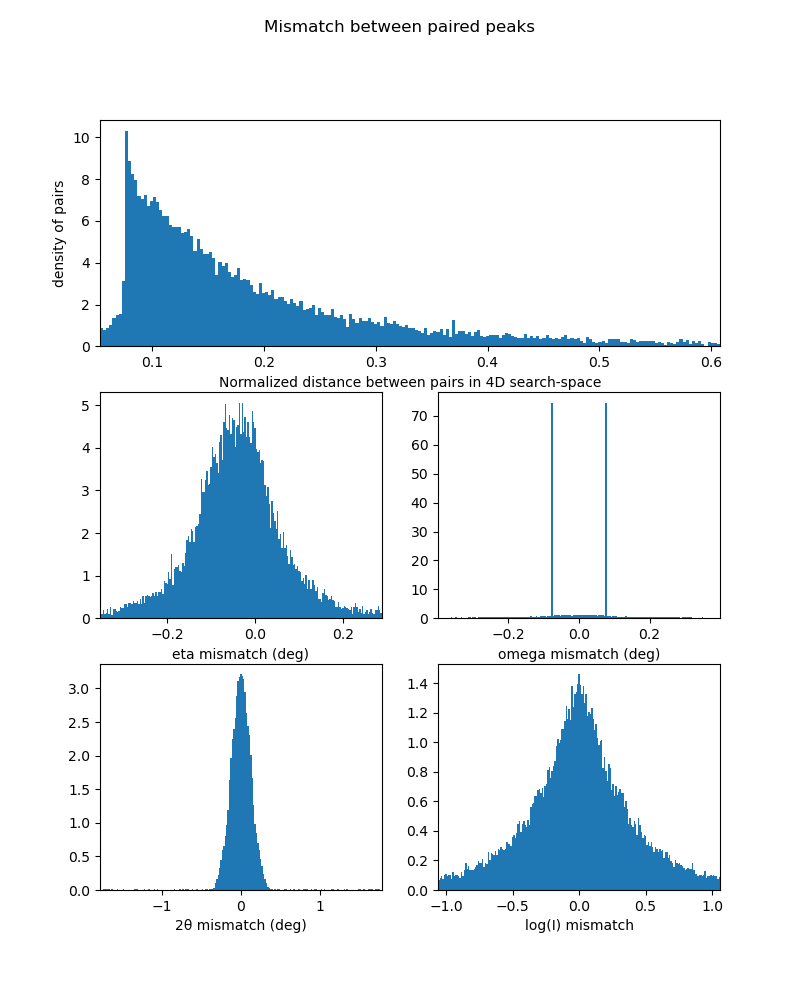

In [223]:
c1, c2 = friedel_pairs.select_y_pair(cf, ds, pair_id = 0)

cp = friedel_pairs.label_friedel_pairs(c1,c2,
                                  dist_max = 0.75,
                                  dist_step = 0.05,
                                  mI=1/5,
                                  mtth=1/5,
                                  verbose=True,
                                  doplot=True)

### Pairing All Y-Pairs

Once satisfied with the results, we can proceed to pair all y-pairs in the dataset. For this, we use the function `find_all_pairs`, which:
- Iterates `label_friedel_pairs` over all y-pairs in the dataset.
- Merges all outputs into a single columnfile.

This function returns a list of paired peakfiles, which is then merged into one peakfile using `merge_outputs`.

**Note:**
By default, this process runs on a single core. However, it is straightforward to parallelize for faster computation. You can use the script [`find_friedel_pairs.py`](https://github.com/jbjacob94/pf_3dxrd/blob/main/pf_3dxrd/scripts/find_friedel_pairs.py) in the `pf_3dxrd/scripts` directory to run the process on multiple cores.

Friedel pair search...


100%|██████████| 55/55 [00:23<00:00,  2.33it/s]


Updating Friedel pair labels


100%|██████████| 54/54 [00:00<00:00, 529.46it/s]


Merging peakfiles...
Friedel pair matching Completed.
N pairs =  1188060
Fraction of peaks matched = 0.78
Fraction of total intensity matched = 0.94


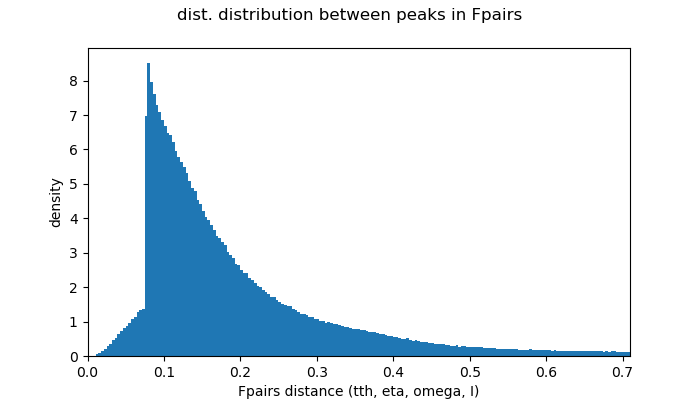

In [224]:
out = friedel_pairs.find_all_pairs(cf,
                                   ds,
                                   dist_max=.75,
                                   dist_step=0.1,
                                   mI=1/5,
                                   mtth=1)


cf_paired, fp_labels, stats = friedel_pairs.merge_outputs(out, cf, doplot=True)

The new peakfile contains two new columns:
   Column   | Description                                                                                     |
 |----------|-------------------------------------------------------------------------------------------------|
 | `fp_id`  | Unique index assigned to each Friedel pair. Each value occurs exactly twice (once per peak).     |
 | `fp_dist`| Euclidean distance (in the 4D search space) between the two peaks of each pair.                 |

**Notes:**
- Non-paired peaks have been removed, so the peakfile now contains only Friedel pairs.
- The `fp_dist` values correspond to the distances plotted in the previous step.

In [225]:
cf_paired.titles

['omega',
 's_raw',
 'f_raw',
 'sum_intensity',
 'dty',
 'number_of_pixels',
 'sc',
 'fc',
 'xl',
 'yl',
 'zl',
 'tth',
 'eta',
 'ds',
 'gx',
 'gy',
 'gz',
 'fp_id',
 'fp_dist']

In [226]:
# show the first 10 pairs. cf has been ordered by fp_id
for t in ['fp_id', 'tth', 'sum_intensity']:
    v = cf_paired.getcolumn(t)[:20]
    print(f'{t}:\n {v}')

np.all(np.equal(cf_paired.fp_id[::2], cf_paired.fp_id[1::2]))

fp_id:
 [0 0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 8 9 9]
tth:
 [10.60646192 10.54945806  8.7301999   8.90496057 11.10855345 11.14889419
  5.72726762  5.76115727 12.3311816  12.4721379  12.85080566 12.95498158
 13.09245284 13.22724255 10.69031045 10.58711245  9.51034079  9.61639709
  7.47672574  7.29591807]
sum_intensity:
 [80516.  68984.5 13063.  12667.5  6464.5  6192.    511.    728.   4847.
  2438.   4852.   6488.  17043.  14657.   2000.   2912.   1644.5  2194.
  4594.5 12247.5]


True

There is also a function to split the columnfile into two symmetrical columnfiles, each containing one peak of each pair

In [227]:
# split Friedel pairs
c1, c2 = friedel_pairs.split_fpairs(cf_paired)
print(f'c1: {c1.fp_id[:10]}')
print(f'c2: {c2.fp_id[:10]}')

c1: [0 1 2 3 4 5 6 7 8 9]
c2: [0 1 2 3 4 5 6 7 8 9]


Typically, the distribution of `fp_dist` is asymmetric, with:
- A **peak close to zero** (indicating most pairs are well-matched).
- A **long tail toward higher values** (some pairs are less well-matched).

**Ideal Distribution:**
- The peak should be as close to zero as possible.
- The tail should decrease sharply with increasing distance.

**Important Notes:**
- There are no strict rules for distinguishing a "good" from a "bad" distribution.
- The shape of the distribution depends significantly on the scaling parameters (`mtth` and `mI`) used for pairing. Larger scaling factors tend yield more spread out distribution.
- Sample size also affects the distribution: larger samples typically result in larger two-theta and intensity mismatch anbd hence broader distance distribution in 4D search space.


We can select a  "low mismatch" and a "large mismatch" subsets among the friedel pairs, and plot the difference in eta, two-theta, etc.

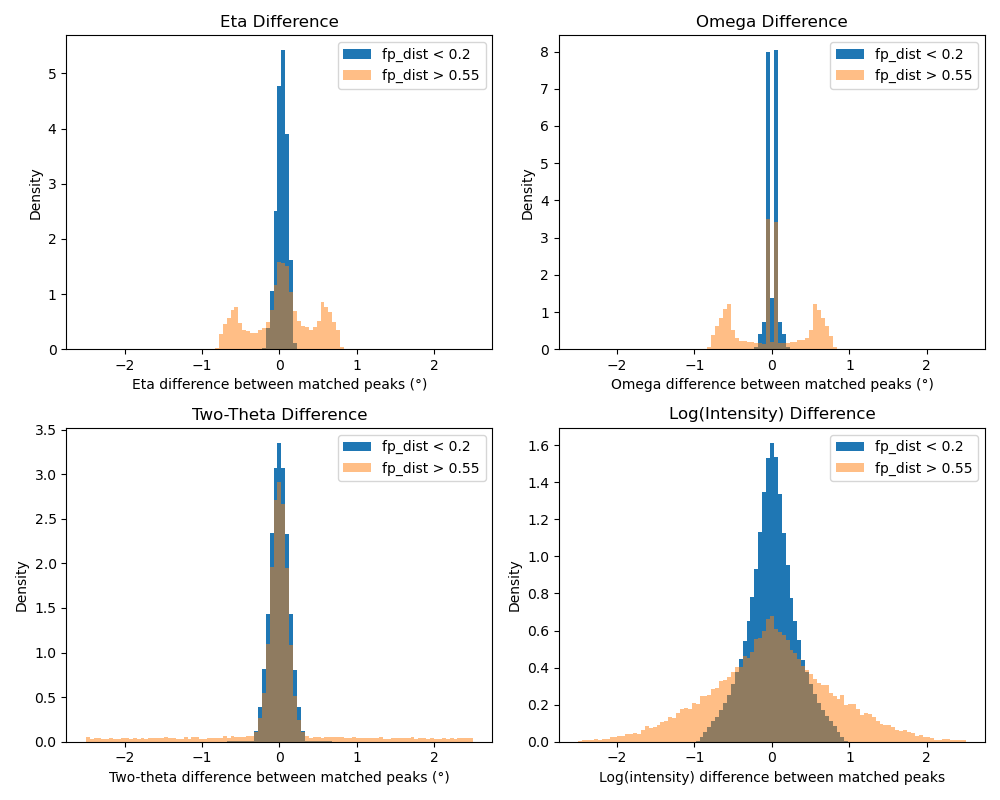

In [228]:
c1, c2 = friedel_pairs.split_fpairs(cf_paired)
dlow, dhigh = 0.2, 0.55
m = c1.fp_dist < dlow
m2 = c1.fp_dist > dhigh

pl.figure(figsize=(10,8))

# Panel 1: Eta difference
pl.subplot(2, 2, 1)
pl.hist(c1.eta[m]%360 - (180-c2.eta[m])%360, bins=np.linspace(-2.5, 2.5, 100), density=True, label=f'fp_dist < {dlow}')
pl.hist(c1.eta[m2]%360 - (180-c2.eta[m2])%360, bins=np.linspace(-2.5, 2.5, 100), alpha=0.5, density=True, label=f'fp_dist > {dhigh}')
pl.xlabel('Eta difference between matched peaks (°)')
pl.ylabel('Density')
pl.legend()
pl.title('Eta Difference')
pl.tight_layout()

# Panel 2: Omega difference
pl.subplot(2, 2, 2)
pl.hist(c1.omega[m]%360 - (180+c2.omega[m])%360, bins=np.linspace(-2.5, 2.5, 100), density=True, label=f'fp_dist < {dlow}')
pl.hist(c1.omega[m2]%360 - (180+c2.omega[m2])%360, bins=np.linspace(-2.5, 2.5, 100), alpha=0.5, density=True, label=f'fp_dist > {dhigh}')
pl.xlabel('Omega difference between matched peaks (°)')
pl.ylabel('Density')
pl.legend()
pl.title('Omega Difference')
pl.tight_layout()

# Panel 3: Two-theta difference
pl.subplot(2, 2, 3)
pl.hist(c1.tth[m] - c2.tth[m], bins=np.linspace(-2.5, 2.5, 100), density=True, label=f'fp_dist < {dlow}')
pl.hist(c1.tth[m2] - c2.tth[m2], bins=np.linspace(-2.5, 2.5, 100), alpha=0.5, density=True, label=f'fp_dist > {dhigh}')
pl.xlabel('Two-theta difference between matched peaks (°)')
pl.ylabel('Density')
pl.legend()
pl.title('Two-Theta Difference')
pl.tight_layout()

# Panel 4: Log-intensity difference
pl.subplot(2, 2, 4)
pl.hist(np.log10(c1.sum_intensity[m]) - np.log10(c2.sum_intensity[m]), bins=np.linspace(-2.5, 2.5, 100), density=True, label=f'fp_dist < {dlow}')
pl.hist(np.log10(c1.sum_intensity[m2]) - np.log10(c2.sum_intensity[m2]), bins=np.linspace(-2.5, 2.5, 100), alpha=0.5, density=True, label=f'fp_dist > {dhigh}')
pl.xlabel('Log(intensity) difference between matched peaks')
pl.ylabel('Density')
pl.legend()
pl.title('Log(Intensity) Difference')
pl.tight_layout()


The analysis shows that large `fp_dist` values mostly correspond to pairs with unrealistic mismatches in **sumI** and, to a lesser extent, **omega**. However, the subset of pairs with large `fp_dist` also contains some good peaks (especially for large samples, where the two-theta mismatch is expected to be large far from the rotation center).

**Trade-off between completeness vs. accuracy of pairing:**
- A **low `dist_max` threshold** yields mostly accurate pairs, but at the expense of completeness.
- A **high `dist_max` threshold** increases completeness, but at the expense of accuracy.

**Recommendation:**
At this stage, it is preferable to **favor completeness** over accuracy. This is because there are several opportunities to clean up the peakfile during subsequent processing steps.

## Geometry Correction

Now that Friedel pairs are labeled, we can exploit them to extract two key pieces of information:
- The **offset from the rotation center**.
- The **correct scattering angle** ($2θ_{cor}$).

#### Background

If a grain is not on the rotation center but translated by an offset ${t}(d_x, d_y, d_z)$, this results in an offset on the detector and inaccurate $2θ$ and $\eta$ values. In classic indexing, ${t}$, $\eta$, and $2θ$ are fitted *a posteriori*, after an initial round of indexing. With Friedel pairs, we can perform this correction **before indexing**, simplifying the process.

#### Simplifying Assumptions

For scanning 3DXRD acquisitions using a thin pencil beam, the beam dimensions in $y$ and $z$ are small. Therefore, we assume the offset occurs **only along the beam direction** (i.e., the $x$-axis). This means only $2θ$ is affected by this offset, not $\eta$. We also know $d_y$, the translation along the $y$-direction during scanning (given by the `dty` column).

#### Mathematical Formulation

For two peaks ($p_1$, $p_2$) forming a Friedel pair:
- The **corrected scattering angle** is:
  $$2θ_{cor} = \frac{1}{2} (t_1 + t_2)$$
- The **offset along $x$** is:
  $$d_x = L \cdot \frac{t_1 - t_2}{t_1 + t_2}$$
where $t_1 = \tan(2θ_1)$ and $t_2 = \tan(2θ_2)$ for $p_1$ and $p_2$, and $L$ is the detector distance from the rotation center.

This yields $2θ_{cor}$, the "real" scattering angle accounting only for $d$-spacing, independent of the offset $d_x$.

#### Relocating Peaks in the Sample Reference Frame

We can use $d_x$ to relocate the peak in the sample reference frame. Since $d_y$ is known, we apply a back-rotation of angle $\omega$ to the coordinates $(d_x, d_y)$ to obtain coordinates in the sample reference frame:
$$(x_s, y_s) = R_{\omega} \cdot (d_x, d_y)$$
where $R_{\omega}$ is the rotation matrix for angle $\omega$.

#### Implementation

These geometric corrections are performed using the function `update_geometry_fpairs` from the `friedel_pairs` module.

In [229]:
friedel_pairs.update_geometry_fpairs(cf_paired, ds, relocate_fpairs=True)
cf_paired.titles

copied an array: size=2376120, elsize=4
copied an array: size=2376120, elsize=4
copied an array: size=2376120, elsize=4
copied an array: size=2376120, elsize=4


['omega',
 's_raw',
 'f_raw',
 'sum_intensity',
 'dty',
 'number_of_pixels',
 'sc',
 'fc',
 'xl',
 'yl',
 'zl',
 'tth',
 'eta',
 'ds',
 'gx',
 'gy',
 'gz',
 'fp_id',
 'fp_dist',
 'xs',
 'ys',
 'r_dist']

The following new columns have been computed or updated:
   Column  | Description                                                                                     |
 |---------|-------------------------------------------------------------------------------------------------|
 | `tth`   | Corrected two-theta angle (in degrees).                                                          |
 | `ds`    | Corrected $d$-spacing (in Å$^{-1}$).                                                             |
 | `(xs, ys)` | Relocated peak position in the sample reference frame.                                         |
 | `r_dist`| Radial distance of the peak source from the rotation center (independent of $\omega$).          |

Now let's have a look to the data. We can first try to compare 2-theta before and after correction

Text(0, 0.5, 'probability density')

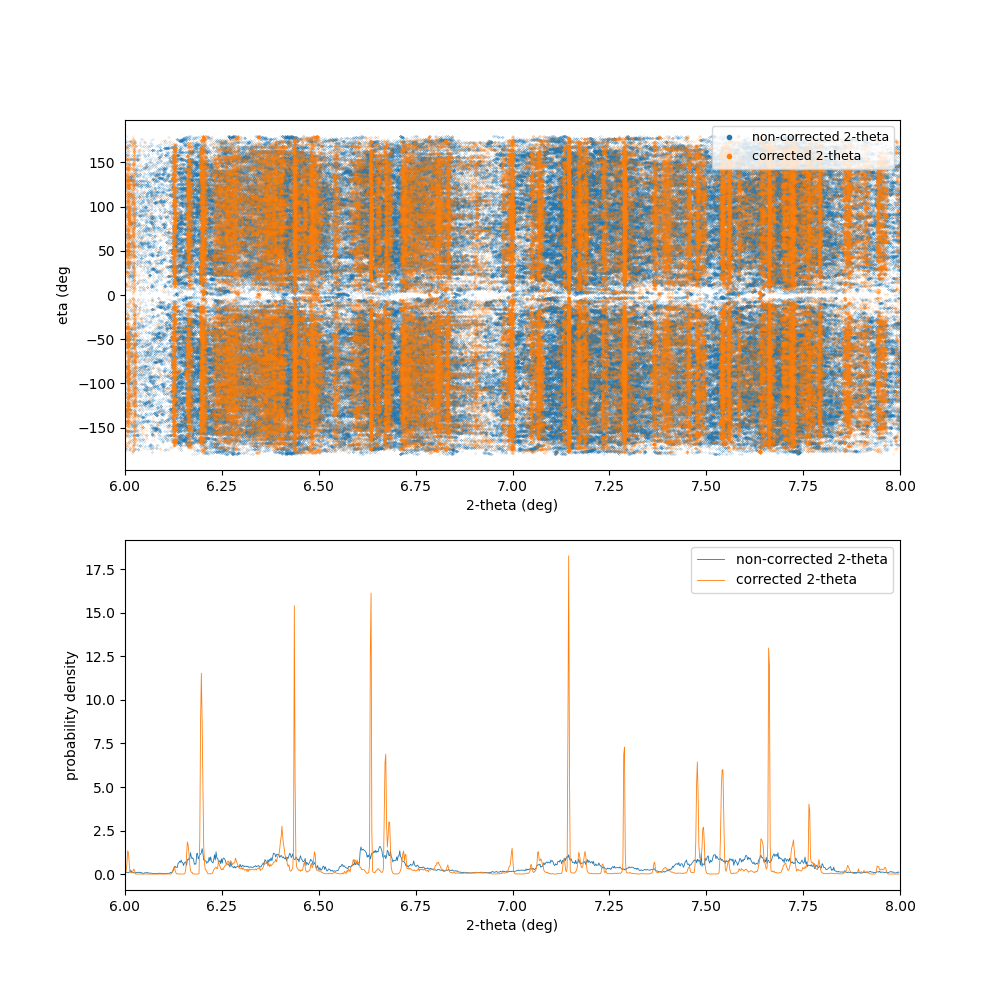

In [230]:
# plot 2-theta vs. eta for corrected vs non-corrected tth on a subset of the two-theta range
tthmin, tthmax = 6,8

fig = pl.figure(figsize=(10,10))
fig.add_subplot(211)
pl.plot(cf.tth, cf.eta, '.', ms = .2, label='non-corrected 2-theta') 
pl.plot(cf_paired.tth, cf_paired.eta, '.', ms=.2, label='corrected 2-theta')
pl.xlabel('2-theta (deg)')
pl.ylabel('eta (deg')
pl.xlim(tthmin, tthmax)
pl.legend(markerscale=30, loc='upper right', fontsize=9) 

# 2-theta histogram for corrected vs non-corrected peaks
fig.add_subplot(212)
h,b,_ = utils.compute_tth_histogram(cf, tthmin=tthmin, tthmax = tthmax, tthstep = 0.002,
                                    uself = True, doplot=False, density=True)
hc,bc,_ = utils.compute_tth_histogram(cf_paired, tthmin=tthmin, tthmax = tthmax, tthstep = 0.002,
                                      uself = True, doplot=False, density=True)

pl.plot(b,h,'-', lw=.6, label='non-corrected 2-theta')
pl.plot(bc,hc,'-',lw=.6, label='corrected 2-theta')
pl.legend()
pl.xlim(tthmin, tthmax)
pl.xlabel('2-theta (deg)')
pl.ylabel('probability density')


#### Comparison with computed hkl rings

There is a sharp reduction in the 2-theta spread when using corrected peak coordinates, and we can see some peaks emerging in the distribution. Now we want to check if these peaks match the predicted Bragg peaks for the different phases in the sample. 

To do this, we need to compute the theoretical two-theta positions of these peaks for each phase in the sample. This can be done using ImageD11 functions and loading multiple parameter files. However, this approach becomes impractical when the sample contains more than one or two phases.

Instead, we will use the `crystal_structure.py` module from `pf_3dxrd`. This module is built on other Python packages for X-ray diffraction data, namely `diffpy.structure`, `Dans_Diffraction`, and `orix`. It defines a class `CS` (for crystal_structure), which allows storing crystal structure information directly loaded from a CIF file.

For simplicity, we assume that the phases present in the sample are already known and provide the crystal structures as CIF files. However, depending on your sample, some phases might be unknown and need to be determined beforehand. In that case, you can use the following strategy:
- Export the histogram of corrected $2\theta$ to a text file. This can be trezted as a high resolution powder diffraction pattern, from which the crystallographic phase mixture can be deconvoluted. 
- Import this file into your preferred powder diffraction analysis software, where the two-theta spectrum can be compared against a database of known crystal structures. Once each major phase has been identified, you can perform Le Bail or Rietveld refinement to fit the average lattice parameters more precisely. A good fit of these lattice parameters is important, as it determines how accurately diffraction peaks from a given crystal structure can be picked using two-theta thresholds around each Bragg peak computed from the fitted unit cell.



In [231]:
# define a phase dictionary containign crystal structure information from CIF files (in the /cif folder). Phase names have to match cif file names (e.g. quartz.cif) 
phase_names = ['quartz', 'orthoclase', 'oligoclase', 'biotite', 'magnetite']  # list of phases to consider. depends on dataset:
#phase_names = ['quartz', 'garnet']
phase_dict = {}

# load crystal structures from cif files. They should all be in the /cif folder
for i,p in enumerate(phase_names):
    cs = crystal_structure.load_CS_from_cif(cif_path = f'cif/{p}.cif', name=p, pid=i)
    print(cs)
    phase_dict[p] = cs

CS: quartz, phase_id: 0, spg: P3221, spg_no: 154, lattice: [  4.91325   4.91325   5.41206  90.       90.      120.     ]
CS: orthoclase, phase_id: 1, spg: C1-11, spg_no: 12, lattice: [  8.589  13.013   7.197  90.    116.02   90.   ]
CS: oligoclase, phase_id: 2, spg: C-1, spg_no: 2, lattice: [  8.154  12.823   7.139  94.06  116.5    88.59 ]
CS: biotite, phase_id: 3, spg: C12/m1, spg_no: 12, lattice: [  5.355   9.251  10.246  90.    100.15   90.   ]
CS: magnetite, phase_id: 4, spg: Fd3m, spg_no: 227, lattice: [ 8.3965  8.3965  8.3965 90.     90.     90.    ]


We want to compute the theoretical $2\theta$ positions of Bragg peaks for all these phases. It is possible to obtain these values directly using `ImageD11.unitcell`, but here we will use a slightly more sophisticated approach, which is particularly useful when dealing with complex mixtures of low-symmetry phases. First, we compute a simulated powder spectrum for each phase. Then, we run a peak search on this spectrum (using `scipy.signal`) to identify the $N$ strongest peaks. This approach allows us to retain only the most significant peaks and ignore the numerous, very low-intensity peaks that theoretically exist but are practically barely visible.



Scatter(quartz with 2 atomic positions, 6 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings---
      Powder units: tth
    Isotropic ADPs: True
  Specular Direction (reflection): ( 0, 0, 1)
Parallel Direction (transmission): ( 0, 0, 1)
      theta offset: 0.0
         min theta: -180.0
         max theta: 180.0
      min twotheta: 2
      max twotheta: 13.299999140608184
 ---X-Ray Settings---
 Waasmaier scattering factor: False
 ---Neutron Settings---
 Sears (ITC) scattering lengths: False
 ---Magnetic Settings---
   Mag. scattering: True
  Mag. form factor: True
         Polarised: False
      Polarisation: sp
       Pol. vector: (0,1,0)
 ---Resonant Settings---
   Azimuthal angle: 0
    Azimuthal ref.: (1,0,0)
               flm: (0,1,0)
  use e1e1 approx.: True

Scatter(orthoclase with 18 atomic positions, 4 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings

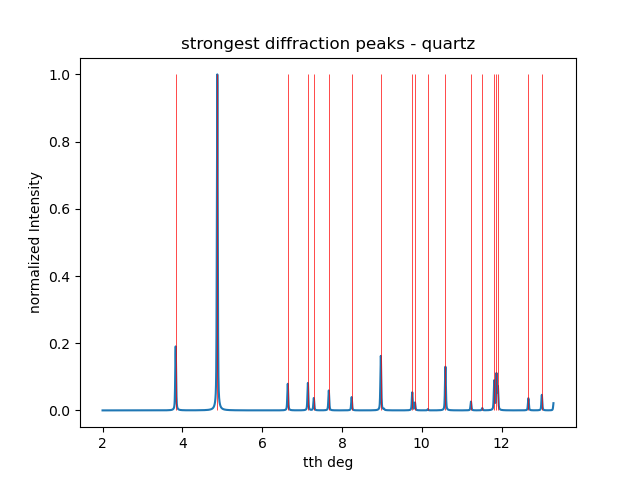

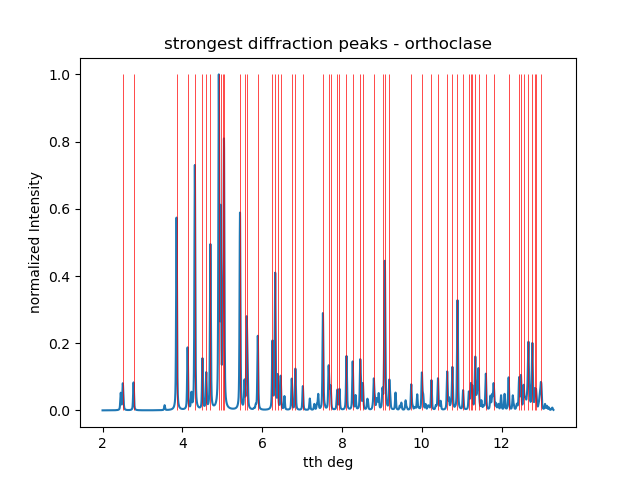

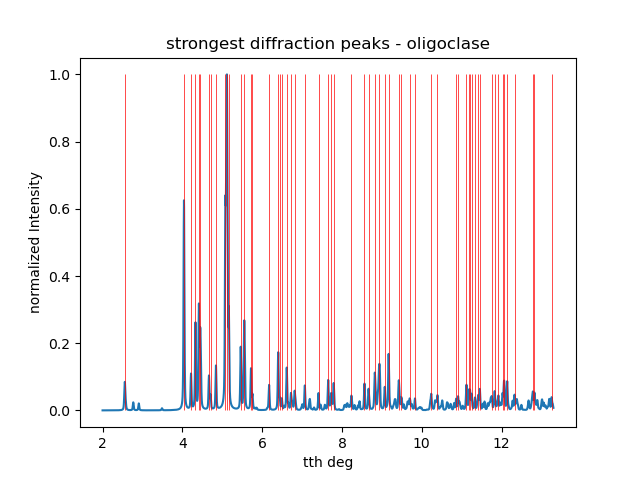

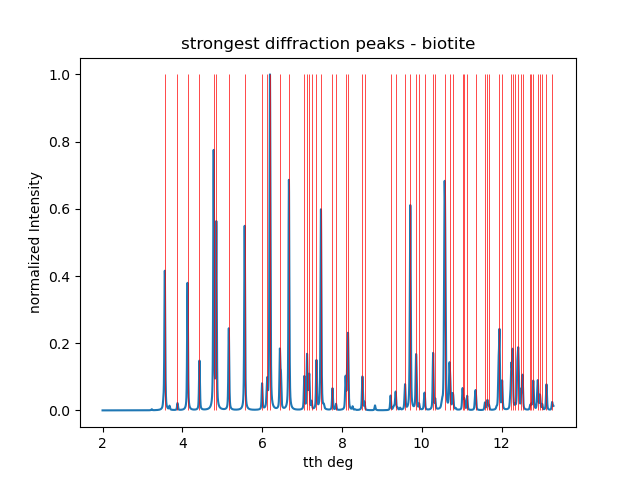

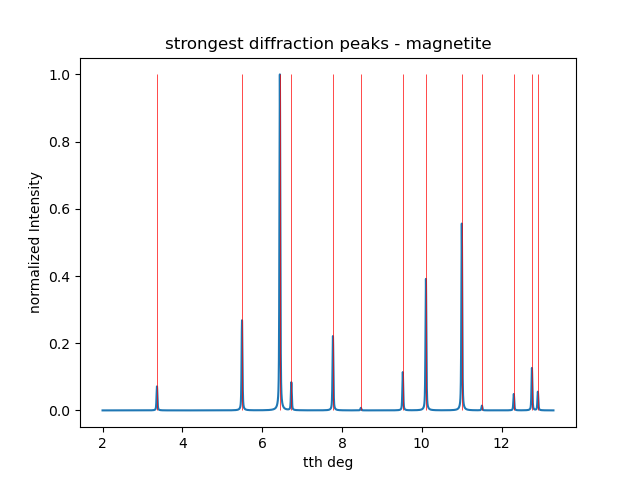

In [233]:
wl = cf.parameters.get('wavelength')  # X-ray wavelength

for cs in phase_dict.values():
    # simulated powder spectrum
    cs.compute_powder_spec(wl, min_tth=2, max_tth=cf.tth.max(), doplot=False)
    
    # peak search in the powder spectrum. Imin is the min intensity relative to the strongest peak. 
    # prominence measures how much a peak stands out from the surrounding baseline of the signal (cf scipy.signal)
    cs.find_strongest_peaks(Imin=0.001, prominence=0.001, Nmax=60, doplot=True) 

Now we can replot the data with these theoretical peaks

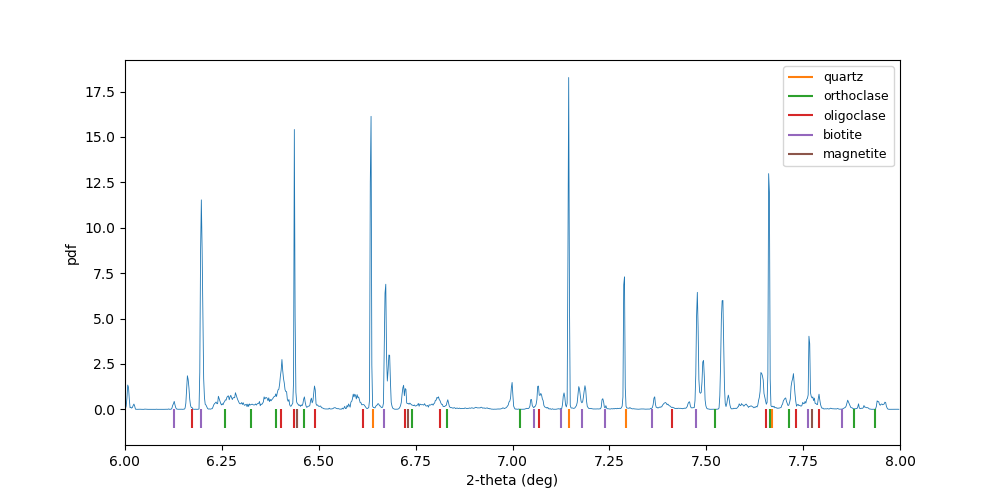

In [234]:
# replot 2θ vs η and add computed hkl ring positions for each phase
colors = pl.matplotlib.cm.tab10.colors

pl.figure(figsize=(10,5))
pl.plot(bc,hc, '-', lw=.6)

for p,cs in phase_dict.items():
    pl.vlines(cs.strong_peaks[0], -1,0, colors = colors[cs.phase_id+1], label=p)
pl.xlabel('2-theta (deg)')
pl.ylabel('pdf')
pl.xlim(tthmin, tthmax)

pl.legend(loc='upper right', fontsize=9) 

The match between theoretical Bragg peaks and the observed peaks in the distribution looks quite good, at least for quartz.  
There is a slight mismatch, particularly for orthoclase and oligoclase. These phases are more challenging because they are not pure compounds but form solid solutions, leading to significant variation in lattice parameters with composition. 

### Sample reconstruction

There is one last step we can do in this first part of the tutorial. In addition to the corrected $2\theta$, we also have the $(x_s, y_s)$ coordinates of each diffraction peak in the sample reference frame. Let's try plotting these data as a 2D histogram.


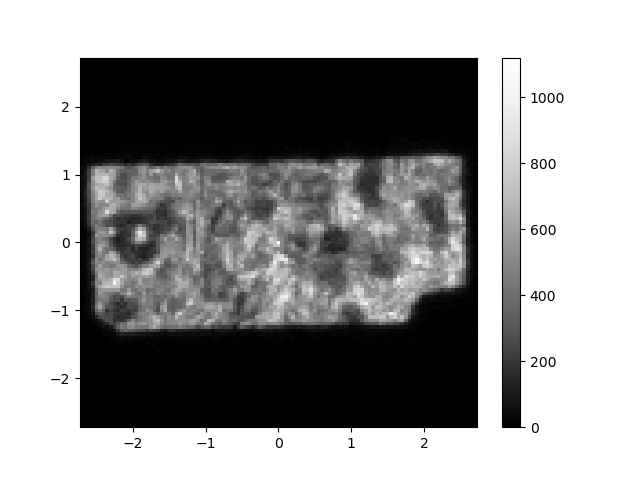

In [235]:
pl.figure()
cmap = pl.matplotlib.cm.Greys_r.copy()
cmap.set_extremes(under='k', over='w')

pl.hist2d(cf_paired.xs, cf_paired.ys, bins = ds.ybinedges, cmap=cmap);
pl.colorbar()

And we get a nice map showing the diffraction intensity across the sample. Bright domains diffract more strongly than dark domains. We can filter out peaks outside the ROI, to keep only portions of the map with complete data. 

In [236]:
cf_paired.filter(cf_paired.r_dist <= ds.ybinedges.max())

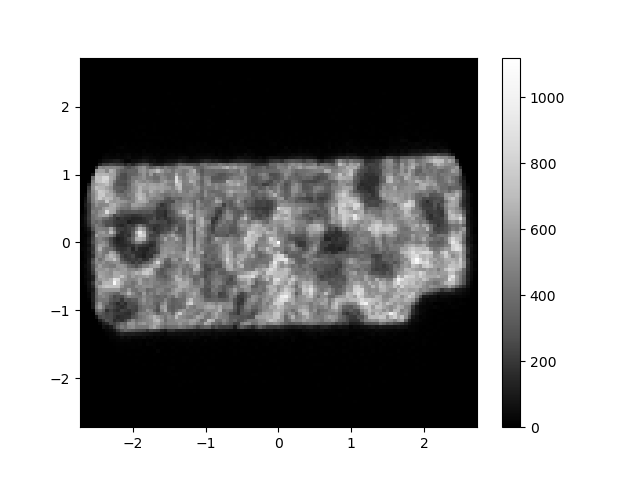

In [237]:
pl.figure()

pl.hist2d(cf_paired.xs, cf_paired.ys, bins = ds.ybinedges, cmap=cmap);
pl.colorbar()

There is also a function in the `utils` module to make this plot. It allows to select subsets of peaks for plotting, e.g, a small rectangular ROI in the sample, or to subset by crystal phase. Let's try it with quartz.

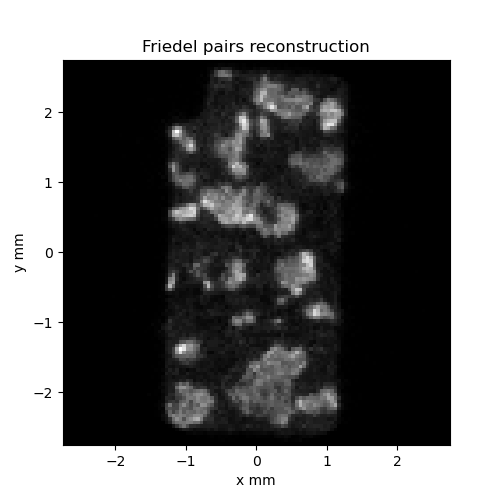

In [238]:
# compute mask for quartz. select_tth_rings returns a mask with all peaks within a certain distance of theoretical tth rings for quartz.
# see doctstring for more info.
mask_qtz = utils.select_tth_rings_fast(cf_paired, phase_dict['quartz'].strong_peaks[0], tth_tol=0.02, tth_max=cf.tth.max())

kw = {'cmap':'Greys_r'}   # keyword arguments to pass to plot function

# plot reconstruction for quartz peaks only
utils.friedel_recon(cf_paired,
                    xbins = ds.ybinedges,
                    ybins = ds.ybinedges,
                    doplot=True,
                    mask = mask_qtz,
                    weight_by_intensity=True,
                    norm = True,
                    **kw );

We clearly see the quartz grains appearing, but there is still some background signal from outside of these grains. This results either from dodgy Friedel pairs which were wrongly relocated, or from overlaps between different Bragg peaks from different phases, which inevitably results in wrong selection of some peaks. In the next tutorial, we will see how we can improve that and make a better phase map. 

### Save peakfile

To finish, we need to save these data. We will create a new peakfile named `"datasetname_pks_p.h5"` to avoid overwriting the raw peak file.

While there is a function in `ImageD11.columnfile` to export column files, here we will use a custom function from the `pf_3dxrd.utils` module. This function performs essentially the same task but ensures that essential information on Friedel pairs (namely, `fp_id` and `fp_dist`) is preserved.

In [32]:
# save data. The 'minimal' save mode means that only the necessary data columns are kept. All data that can be recomputed from other columns are dropped.
utils.colf_to_hdf(cf_paired, os.path.join(data_dir, dsname+'_pk2d_p.h5'), save_mode='minimal')